# WG FA — Distributions des features : signal vs background

**Collaboration B · Working Group FA (Feature Analysis) · dataset HiggsML / FAIR Universe (canal H→ττ)**

Ce notebook :
1. charge le dataset via le *starting kit* (`HiggsML.datasets.download_dataset`) ;
2. sépare les événements **signal** (`htautau`) et **background** (`ztautau`, `ttbar`, `diboson`) ;
3. trace pour chaque feature un histogramme **superposant signal et background**, **normalisé en aire** (`density=True`) pour comparer les *formes*, et **pondéré par les poids** des événements ;
4. présente le tout en deux grilles distinctes : variables **PRImaires** (`PRI_*`) et variables **DERivées** (`DER_*`).

> Les distributions sont normalisées en aire car le background domine très largement en poids (somme des poids ≈ 105 000 contre ≈ 680 pour le signal) : sans normalisation, la forme du signal serait invisible.

In [8]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Chargement du dataset via le starting kit

`download_dataset("blackSwan_data")` réutilise le dossier local `blackSwan_data/` s'il existe déjà (sinon il le télécharge depuis Codabench). On se place donc dans le dossier qui le contient.

On trace **l'intégralité** des 2 000 000 d'événements du parquet. Par défaut le loader réserve 30 % des événements en jeu de test (`test_size=0.3`) : on met `test_size = 0` pour tout charger.

In [9]:
# Localiser le dossier contenant le cache local "blackSwan_data"
# (robuste quel que soit l'endroit d'où le notebook est lancé : FA/, racine du repo, ...).
DATA_ROOT = None
for base in [Path.cwd(), *Path.cwd().parents]:
    for cand in (base, base / "Higgs_collaborations-main"):
        if (cand / "blackSwan_data").is_dir():
            DATA_ROOT = cand
            break
    if DATA_ROOT:
        break
assert DATA_ROOT is not None, "Dossier 'blackSwan_data' introuvable."
os.chdir(DATA_ROOT)
print("Répertoire de travail :", DATA_ROOT)

from HiggsML.datasets import download_dataset

data = download_dataset("blackSwan_data")

# On trace TOUTES les données du dossier starting kit. Le loader réserve par défaut
# 30 % des événements en jeu de test (test_size=0.3) ; on met test_size = 0 pour
# charger l'intégralité du parquet (2 000 000 d'événements).
data.test_size = 0
data.load_train_set()
# (pour itérer plus vite, on peut échantillonner, ex. : data.load_train_set(train_size=500_000))
df = data.get_train_set()
print("Données chargées :", df.shape[0], "événements ×", df.shape[1], "colonnes")

2026-06-02 09:31:10,404 - HiggsML.datasets     - INFO     - Handling as dataset name: blackSwan_data
2026-06-02 09:31:10,426 - HiggsML.datasets     - INFO     - Current working directory: /Users/baptisteblasini/Documents/Higgs-TeamB/Higgs_collaborations-main
2026-06-02 09:31:10,446 - HiggsML.datasets     - INFO     - Total rows: 2000000
2026-06-02 09:31:10,446 - HiggsML.datasets     - INFO     - Test size: 600000
2026-06-02 09:31:10,558 - HiggsML.datasets     - INFO     - Selected train size: 2000000


Répertoire de travail : /Users/baptisteblasini/Documents/Higgs-TeamB/Higgs_collaborations-main


2026-06-02 09:31:11,431 - HiggsML.datasets     - INFO     - Data loaded successfully


Données chargées : 2000000 événements × 31 colonnes


## 2. Séparation signal / background

`labels == 1` → **signal** (`htautau`) ; `labels == 0` → **background**. La colonne `weights` contient les poids physiques des événements ; `detailed_labels` donne le processus précis.

In [10]:
labels = df["labels"].to_numpy()
weights = df["weights"].to_numpy()
is_signal = labels == 1
is_background = labels == 0

# Résumé par processus (effectifs et poids)
summary = (
    df.groupby("detailed_labels")
      .agg(n_events=("weights", "size"), sum_weights=("weights", "sum"))
      .sort_values("sum_weights", ascending=False)
)
print(summary, "\n")
print(f"SIGNAL     : {is_signal.sum():>8d} évts | somme des poids = {weights[is_signal].sum():>10.1f}")
print(f"BACKGROUND : {is_background.sum():>8d} évts | somme des poids = {weights[is_background].sum():>10.1f}")

                 n_events    sum_weights
detailed_labels                         
ztautau           1277179  100257.499888
ttbar               56084    4402.426078
htautau            661870     676.608318
diboson              4867     382.465715 

SIGNAL     :   661870 évts | somme des poids =      676.6
BACKGROUND :  1338130 évts | somme des poids =   105042.4


## 3. Variables PRImaires vs DERivées

- **`PRI_*`** : quantités *primaires*, mesurées directement (impulsions, pseudo-rapidités, angles azimutaux, énergie transverse manquante…).
- **`DER_*`** : quantités *dérivées*, calculées à partir des primaires (masses, ΔR, centralités…).

**Valeur sentinelle `-25`** : certaines variables de jets ne sont pas définies quand l'événement n'a pas assez de jets (p. ex. les variables di-jet exigent ≥ 2 jets). Ces cas sont codés `-25`. On les **masque** avant de tracer (sinon un pic artificiel à `-25` écrase la vraie distribution) et on **annote la fraction d'événements non définis** pour le signal (S) et le background (B).

In [11]:
NON_FEATURES = {"weights", "labels", "detailed_labels"}
pri_features = [c for c in df.columns if c.startswith("PRI_") and c not in NON_FEATURES]
der_features = [c for c in df.columns if c.startswith("DER_") and c not in NON_FEATURES]
SENTINEL = -25.0  # valeur codant une quantité (de jet) non définie

print(f"{len(pri_features)} variables PRImaires :", pri_features)
print(f"{len(der_features)} variables DERivées  :", der_features)

16 variables PRImaires : ['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets', 'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi']
12 variables DERivées  : ['DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_had', 'DER_met_phi_centrality', 'DER_lep_eta_centrality']


## 4. Fonction de tracé

Pour chaque feature : histogrammes **superposés** signal (trait bleu) et background (aire rouge), **pondérés** (`weights`) et **normalisés en aire** (`density=True`) pour comparer les formes. Détails :
- masquage de la sentinelle `-25` ;
- intervalle robuste (percentiles 0.5–99.5 %) pour ignorer les queues extrêmes ;
- bins entiers pour les variables de comptage (`PRI_n_jets`) ;
- unités physiques indiquées sur l'axe des x quand elles sont connues.

In [12]:
def _xlabel(col):
    """Ajoute l'unité physique au nom de la variable quand elle est connue."""
    low = col.lower()
    if "centrality" in low or "ratio" in low or "eta" in low:
        unit = ""          # pseudo-rapidités, ratios, centralités : sans dimension
    elif "phi" in low:
        unit = "rad"
    elif "n_jets" in low:
        unit = ""          # comptage
    elif ("pt" in low) or ("mass" in low) or ("met" in low):
        unit = "GeV"
    else:
        unit = ""
    return f"{col} [{unit}]" if unit else col


def plot_feature_grid(df, features, suptitle, n_cols=4, n_bins=40,
                      q=(0.5, 99.5), sentinel=SENTINEL):
    """Grille d'histogrammes signal vs background (formes normalisées, pondérées)."""
    sig = df["labels"].to_numpy() == 1
    bkg = df["labels"].to_numpy() == 0
    w = df["weights"].to_numpy()

    n = len(features)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    c_sig, c_bkg = "#1f4fd8", "#d62728"
    for i, col in enumerate(features):
        ax = axes[i]
        x = df[col].to_numpy()
        defined = x != sentinel                  # masque la sentinelle -25
        ms, mb = defined & sig, defined & bkg
        xd = x[defined]
        if xd.size == 0:
            ax.set_visible(False)
            continue

        # binning : bins entiers pour les comptages, intervalle robuste sinon
        uniq = np.unique(xd)
        if uniq.size <= 15 and np.allclose(uniq, np.round(uniq)):
            bins = np.arange(uniq.min() - 0.5, uniq.max() + 1.5, 1.0)
        else:
            lo, hi = np.percentile(xd, q)
            if lo == hi:
                lo, hi = xd.min(), xd.max()
            bins = np.linspace(lo, hi, n_bins + 1)

        ax.hist(x[mb], bins=bins, weights=w[mb], density=True,
                histtype="stepfilled", color=c_bkg, alpha=0.40, edgecolor=c_bkg, lw=0.8)
        ax.hist(x[ms], bins=bins, weights=w[ms], density=True,
                histtype="step", color=c_sig, lw=2.0)

        ax.set_xlabel(_xlabel(col), fontsize=9)
        ax.set_ylabel("densité (aire = 1)", fontsize=8)
        ax.tick_params(labelsize=8)

        undef = 1.0 - defined.mean()
        if undef > 0.001:                        # annoter la fraction non définie
            us = 1.0 - ms.sum() / max(sig.sum(), 1)
            ub = 1.0 - mb.sum() / max(bkg.sum(), 1)
            ax.set_title(f"{col}\nnon défini : S {us:.0%} / B {ub:.0%}", fontsize=9)
        else:
            ax.set_title(col, fontsize=10)

    for j in range(n, len(axes)):               # masquer les cases vides
        fig.delaxes(axes[j])

    handles = [
        Patch(facecolor=c_bkg, alpha=0.40, edgecolor=c_bkg,
              label="Background (Z→ττ, tt̄, diboson)"),
        Line2D([0], [0], color=c_sig, lw=2.0, label="Signal (H→ττ)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=12,
               frameon=True, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(suptitle, fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

## 5. Distributions des variables PRImaires (`PRI_*`)

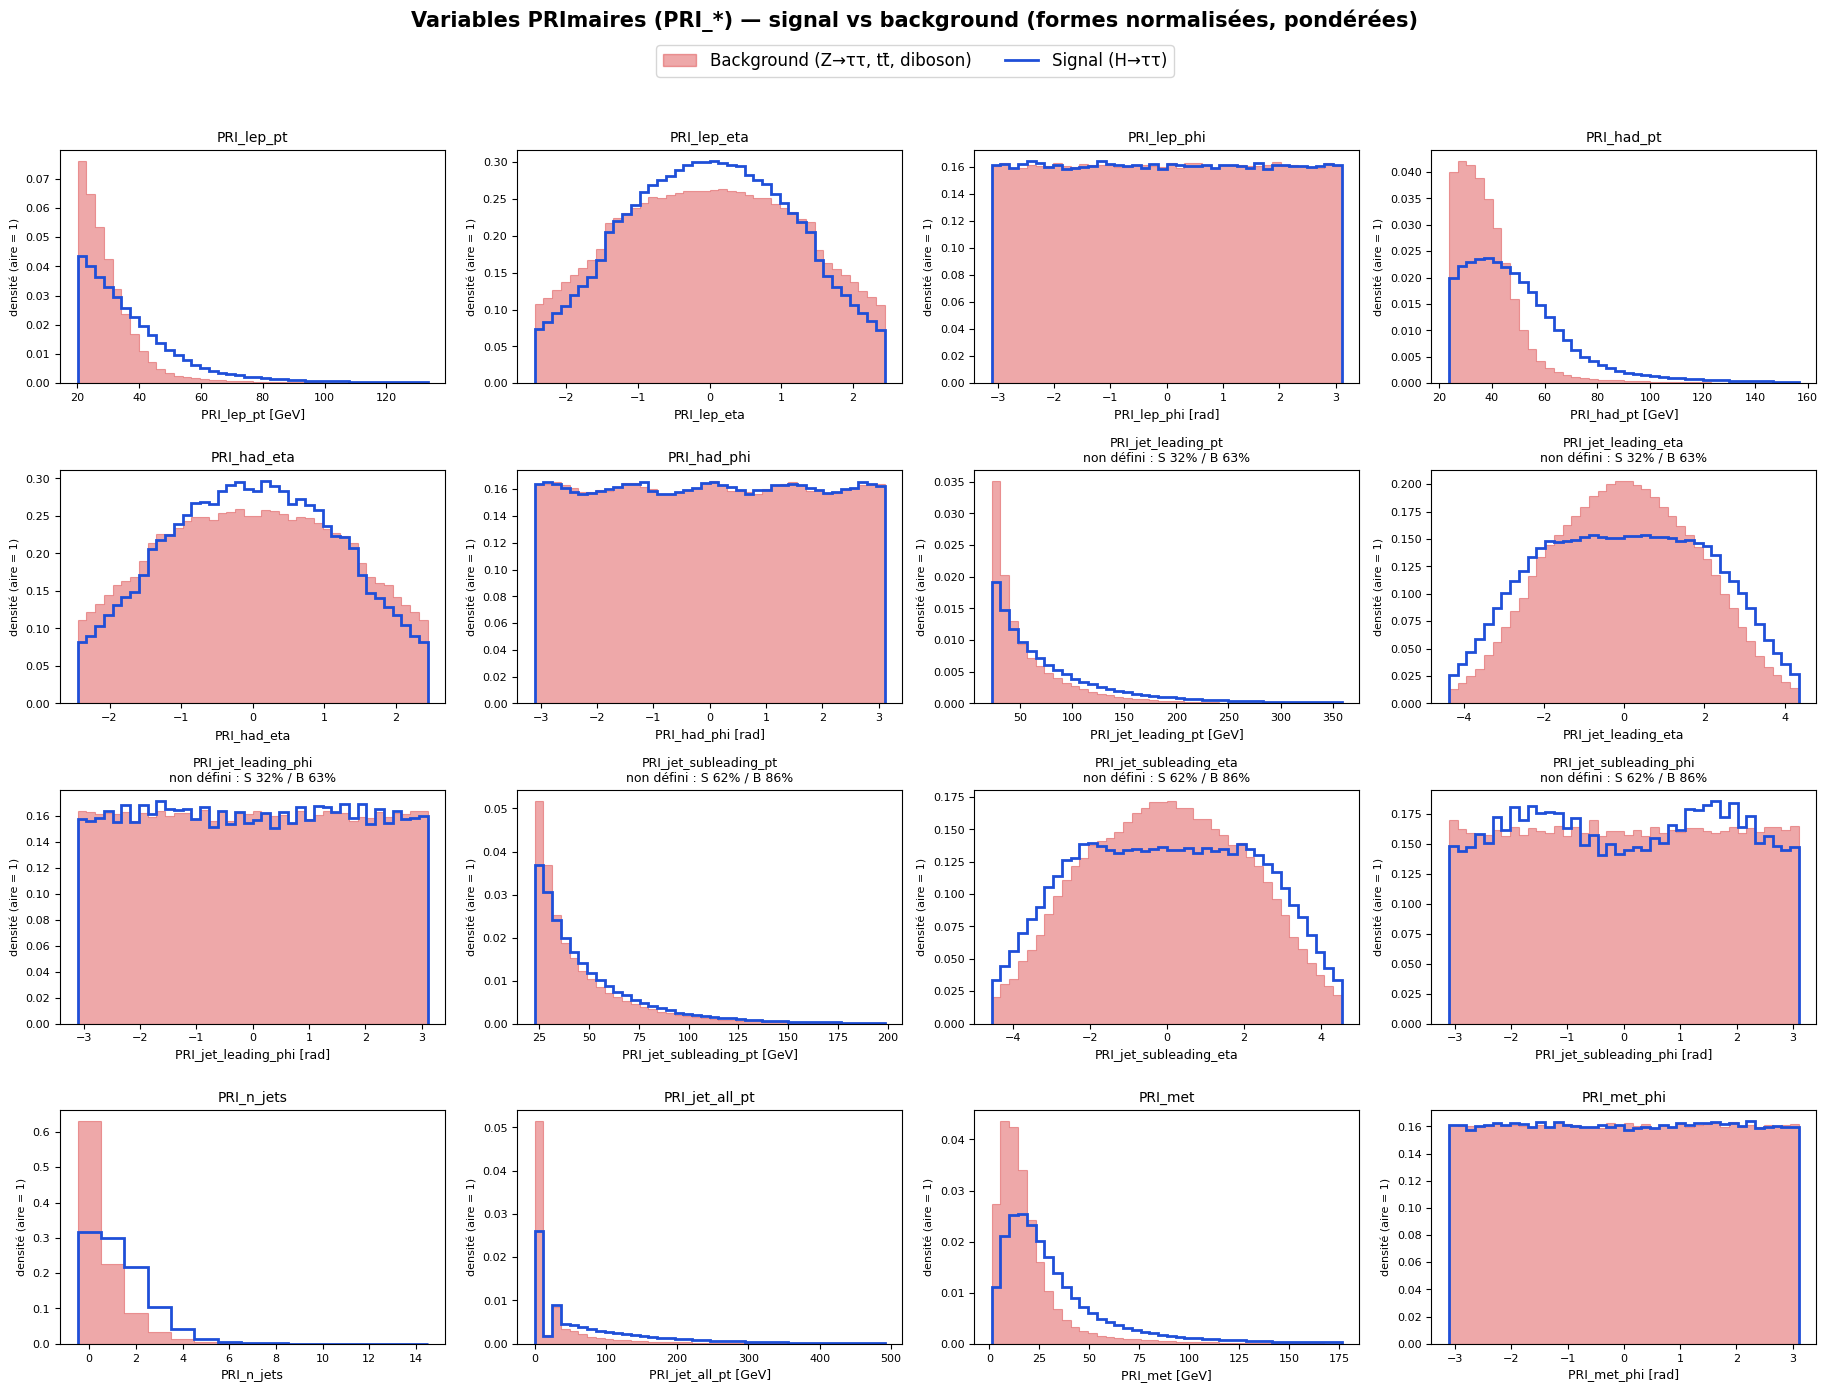

In [13]:
plot_feature_grid(
    df, pri_features,
    "Variables PRImaires (PRI_*) — signal vs background (formes normalisées, pondérées)",
)
plt.show()

## 6. Distributions des variables DERivées (`DER_*`)

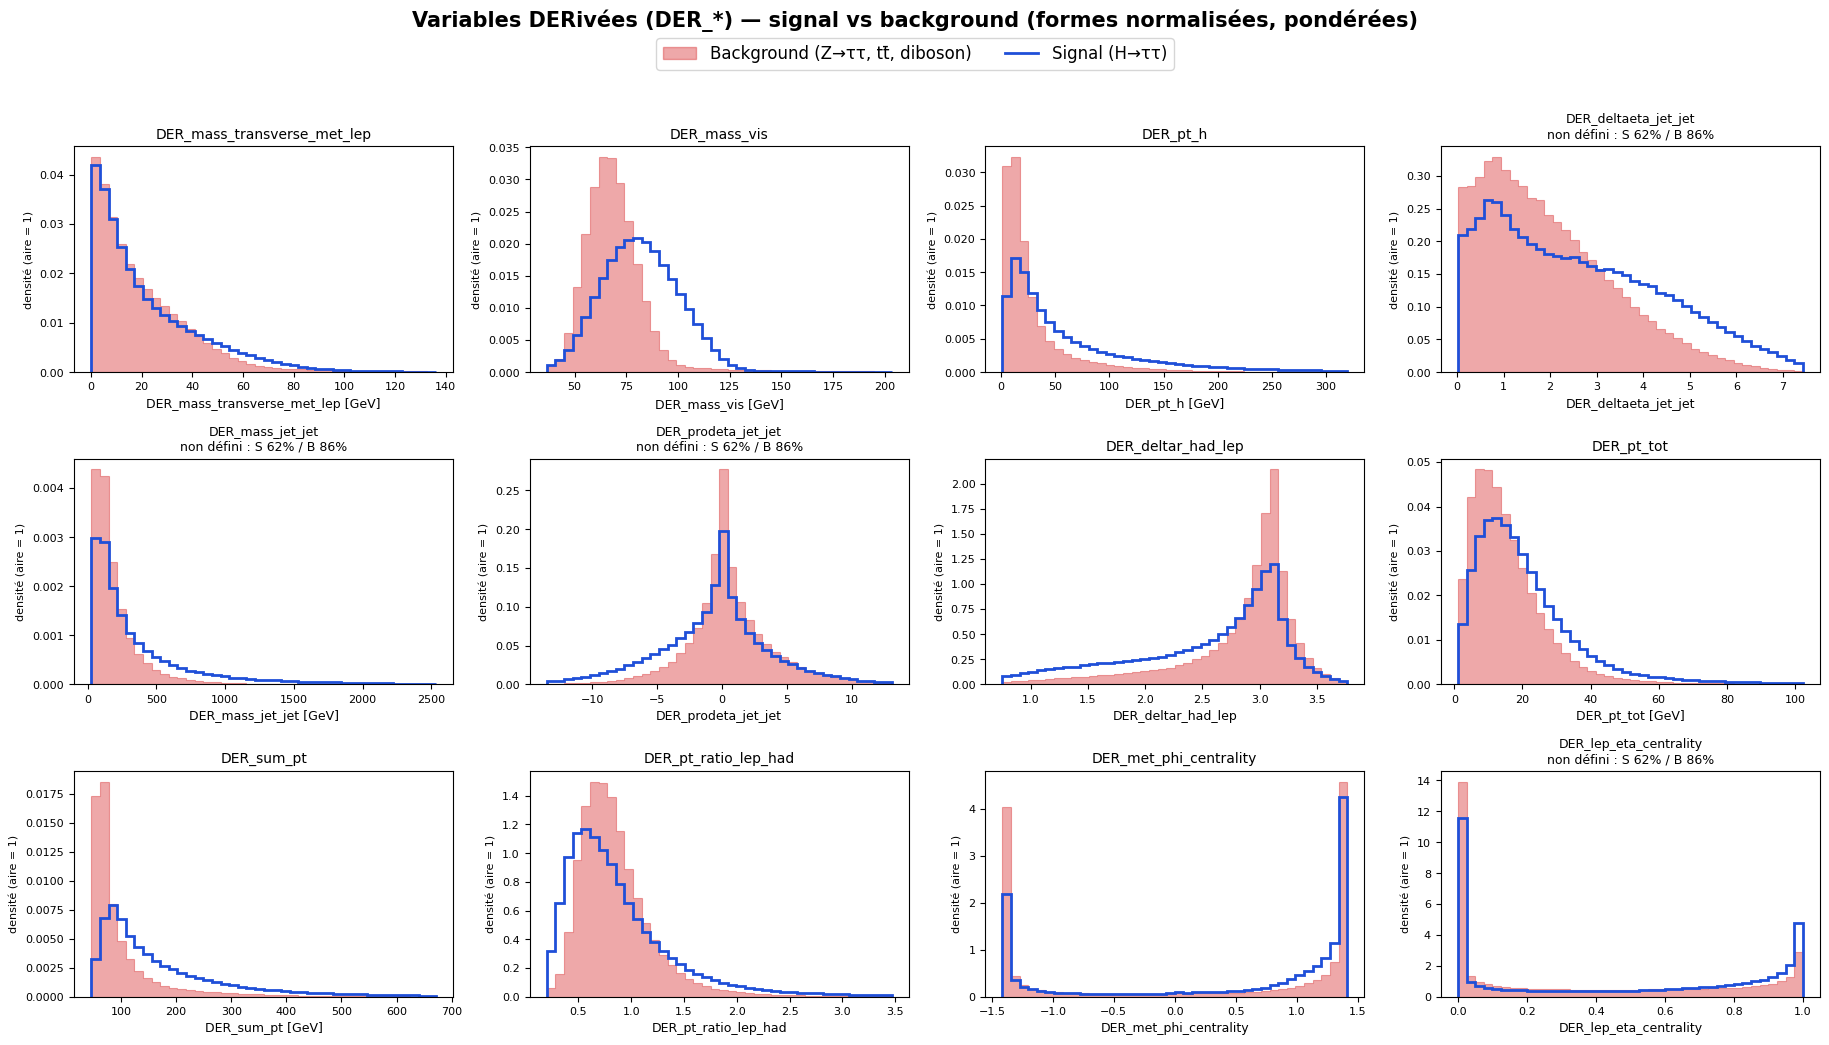

In [14]:
plot_feature_grid(
    df, der_features,
    "Variables DERivées (DER_*) — signal vs background (formes normalisées, pondérées)",
)
plt.show()

## Lecture rapide (quelques pistes pour le WG FA)

- **Variables les plus discriminantes** : `DER_mass_vis`, `DER_mass_transverse_met_lep`, `DER_pt_h`, `DER_deltar_had_lep`, `DER_pt_ratio_lep_had`, `DER_deltaeta_jet_jet` — formes signal/background nettement différentes.
- **`PRI_*_phi`** : distributions plates → peu discriminantes telles quelles (piste *feature engineering* : remplacer `phi` par `cos/sin(phi)`, ou utiliser des différences Δφ).
- **Variables de jets** : le signal H→ττ a en moyenne **plus de jets** que le background (fractions « non défini » plus faibles pour S), signature de la production associée / VBF — cohérent avec un `DER_deltaeta_jet_jet` plus grand pour le signal.

**Prochaines étapes FA** : matrices de corrélation PRI↔DER, feature engineering (phi→cos/sin, pt/eta/phi→px/py/pz) et mesure de l'impact sur le BDT, puis étude de l'importance des features par modèle.